# Práctica Final: Clasificación con Scikit-learn y MLflow

En esta práctica, utilizarás un conjunto de datos de Scikit-learn (podeís usar el mismo que en el notebook de Intro MLFlow) para entrenar un modelo de clasificación.

Pasos a seguir:

    Exploración de Datos: Analiza el conjunto de datos proporcionado para comprender su estructura y contenido.

    Preprocesamiento de Texto: Realiza tareas de preprocesamiento de texto, como tokenización y vectorización, para preparar los datos para el modelado.

    Entrenamiento del Modelo: Utiliza algoritmos de clasificación de Scikit-learn para entrenar un modelo con los datos preprocesados.

    Evaluación del Modelo: Evalúa el rendimiento del modelo utilizando métricas de evaluación estándar como precisión y recall.

    Registro de Métricas con MLflow: Utiliza MLflow para registrar métricas y hiperparámetros durante el entrenamiento, facilitando la gestión y comparación de experimentos.


Nota: Dado que no voy a poder tener acceso a vuestros logs de MLFlow añadirme las imagenes de la interfaz de MLFlow en el notebook

En esta práctica utilizo mi dataset de machine learning, concretamente el dataset de Airbnb listings. En la práctica original, este dataset se utilizaba para construir un modelo de regresión para la predicción del precio. Sin embargo, como en esta práctica se requiere resolver un problema de clasificación, he modificado ligeramente el procesamiento de la variable objetivo (y), clasificando el precio en tres categorías: bajo, medio y alto, de modo que el problema pueda abordarse como un problema de clasificación.

In [1]:
import pandas as pd

df = pd.read_csv("airbnb-listings-extract.csv", sep=";")
print(df.shape)
df.head().T

(14780, 89)


,0,1,2,3,4
ID,11210388,17471131,17584891,5398030,18104606
Listing Url,https://www.airbnb.com/rooms/11210388,https://www.airbnb.com/rooms/17471131,https://www.airbnb.com/rooms/17584891,https://www.airbnb.com/rooms/5398030,https://www.airbnb.com/rooms/18104606
Scrape ID,20170306202425,20170407214050,20170407214050,20170407214050,20170407214050
Last Scraped,2017-03-07,2017-04-08,2017-04-08,2017-04-08,2017-04-08
Name,The Loft-Full Bath-Deck w/View,"Claris I, Friendly Rentals","Style Terrace Red, Friendly Rentals",Picasso Suite 1.4 Paseo de Gracia,Smart City Centre Apartment II
...,...,...,...,...,...
Cancellation Policy,moderate,super_strict_30,super_strict_30,strict,flexible
Calculated host listings count,1.0,106.0,106.0,24.0,92.0
Reviews per Month,3.5,0.86,NaN,1.09,NaN
Geolocation,"30.3373609355,-97.8632766782","41.3896829422,2.17262543017","41.3930345489,2.16217327868","41.3969668101,2.1674178103","41.3886851936,2.15514963616"


Definir el problema de clasificaciòn

In [2]:
import pandas as pd

df = df.copy()

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Eliminar filas sin precio
df = df.dropna(subset=["Price"])

# 3 clases equilibradas (por cuantiles)
df["price_class"] = pd.qcut(df["Price"], q=3, labels=["low", "mid", "high"])

df["price_class"].value_counts()

price_class
low     5080
mid     5000
high    4683
Name: count, dtype: int64

Separar X e y + limpiar columnas “ID”

In [3]:
y = df["price_class"]

# X = features (se quita la target y el Price original)
X = df.drop(columns=["price_class", "Price"])

# se quita columnas tipo id
columns_id = [c for c in X.columns if "id" in c.lower()]
X = X.drop(columns=columns_id)

X.shape, y.shape

((14763, 85), (14763,))

Train/Test Split (Estratificado)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y   #mantener proporciones de clases
)

y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(price_class
 low     0.344115
 mid     0.338696
 high    0.317189
 Name: proportion, dtype: float64,
 price_class
 low     0.344057
 mid     0.338639
 high    0.317304
 Name: proportion, dtype: float64)

Preprocesamiento (numericas y categoricas) con Pipeline

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Columnas numéricas y categóricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "bool"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

Entrenar un clasificador

In [6]:
from sklearn.linear_model import LogisticRegression

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

Entrenar y evaluar

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average="macro")
rec = recall_score(y_test, pred, average="macro")
f1 = f1_score(y_test, pred, average="macro")

acc, prec, rec, f1
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        high       0.83      0.75      0.79       937
         low       0.85      0.90      0.87      1016
         mid       0.70      0.73      0.71      1000

    accuracy                           0.79      2953
   macro avg       0.79      0.79      0.79      2953
weighted avg       0.79      0.79      0.79      2953



Registrar params, métricas y modelo en MLFlow

In [10]:
!pip install mlflow

In [12]:
import mlflow
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
print("tracking_uri:", mlflow.get_tracking_uri())

/home/ruijia/anaconda3/envs/bd16-mlops/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tracking_uri: http://127.0.0.1:5000


In [14]:
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mlflow.set_experiment("airbnb_price_classification")

with mlflow.start_run(run_name="LogReg_baseline"):

    # params
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 2000)
    mlflow.log_param("target", "price_class_qcut_3")

    # train
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    # metrics
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="macro")
    rec = recall_score(y_test, pred, average="macro")
    f1 = f1_score(y_test, pred, average="macro")

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision_macro", prec)
    mlflow.log_metric("recall_macro", rec)
    mlflow.log_metric("f1_macro", f1)

    #matriz de confusion
    fig, ax = plt.subplots(figsize=(6,6))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
    plt.title("Confusion Matrix")
    plt.tight_layout()

    fig_path = "confusion_matrix.png"
    plt.savefig(fig_path)
    plt.close()

    mlflow.log_artifact(fig_path)

    # model
    mlflow.sklearn.log_model(clf, artifact_path="model")

    print(acc, prec, rec, f1)



2026/03/01 12:45:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 12:45:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


0.7920758550626481 0.7939526935889641 0.7906177054709143 0.7912548849241893
🏃 View run LogReg_baseline at: http://127.0.0.1:5000/#/experiments/2/runs/150a16ae51d641a3b287f238b2b6496a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


Lista de runs

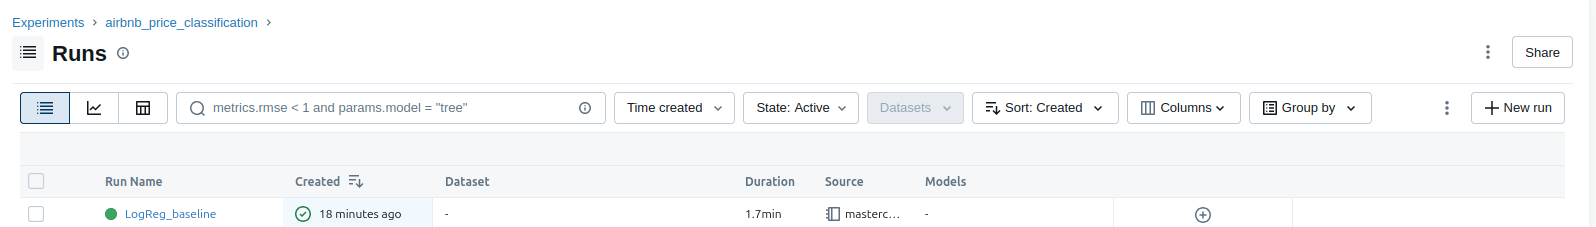

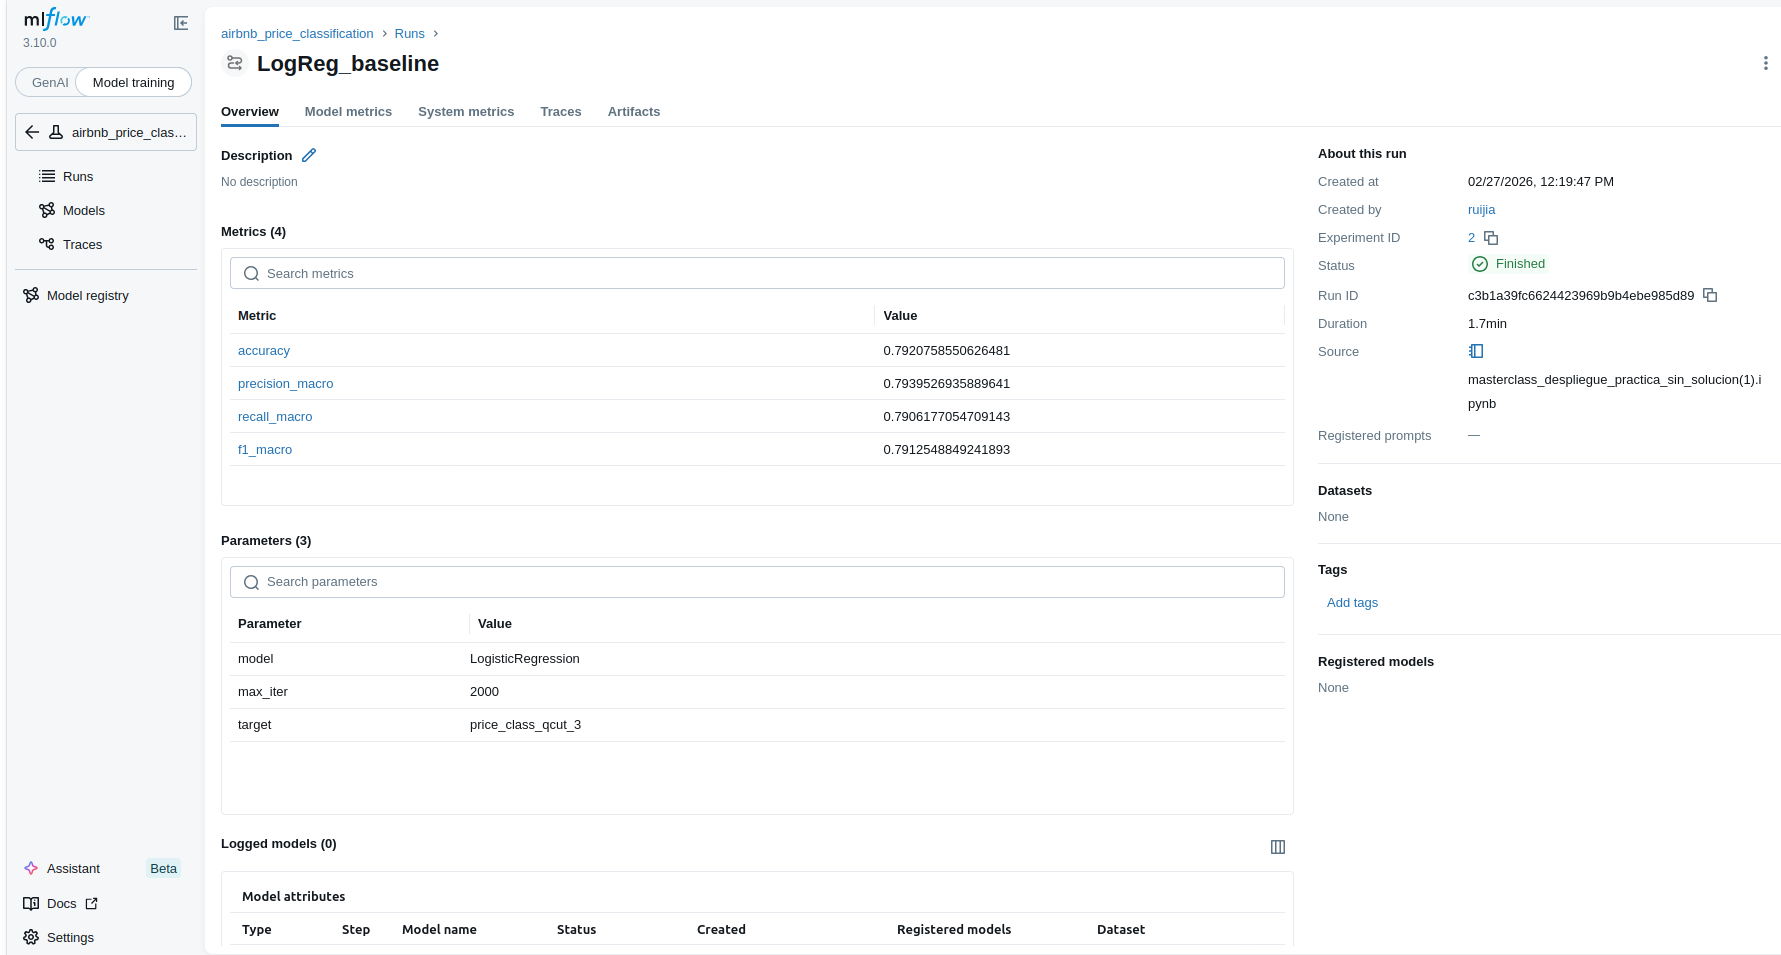

Metrics

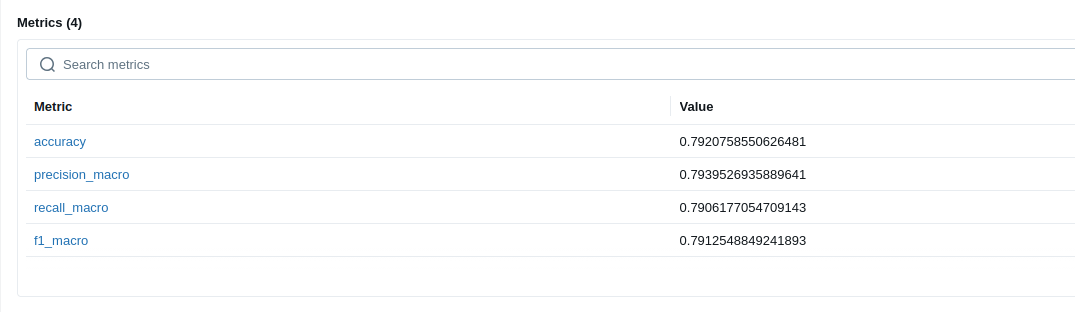

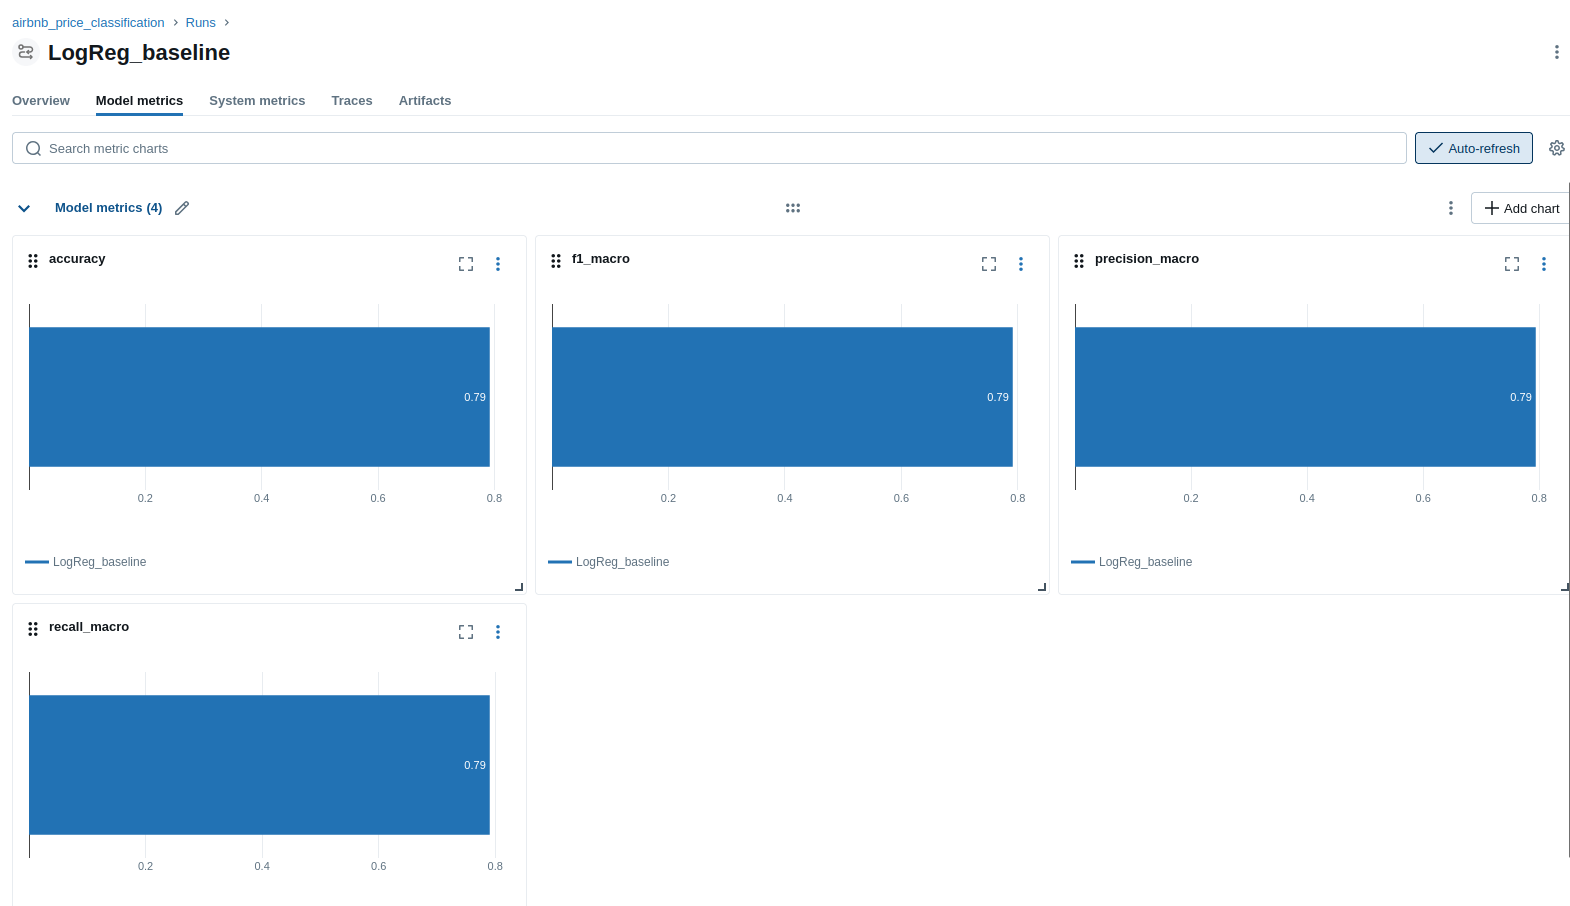

Parameters

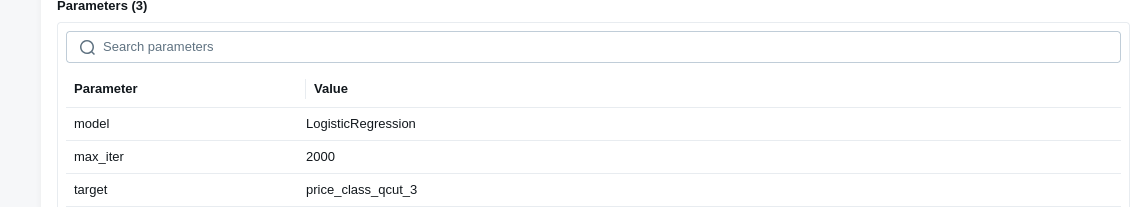

Artifacts

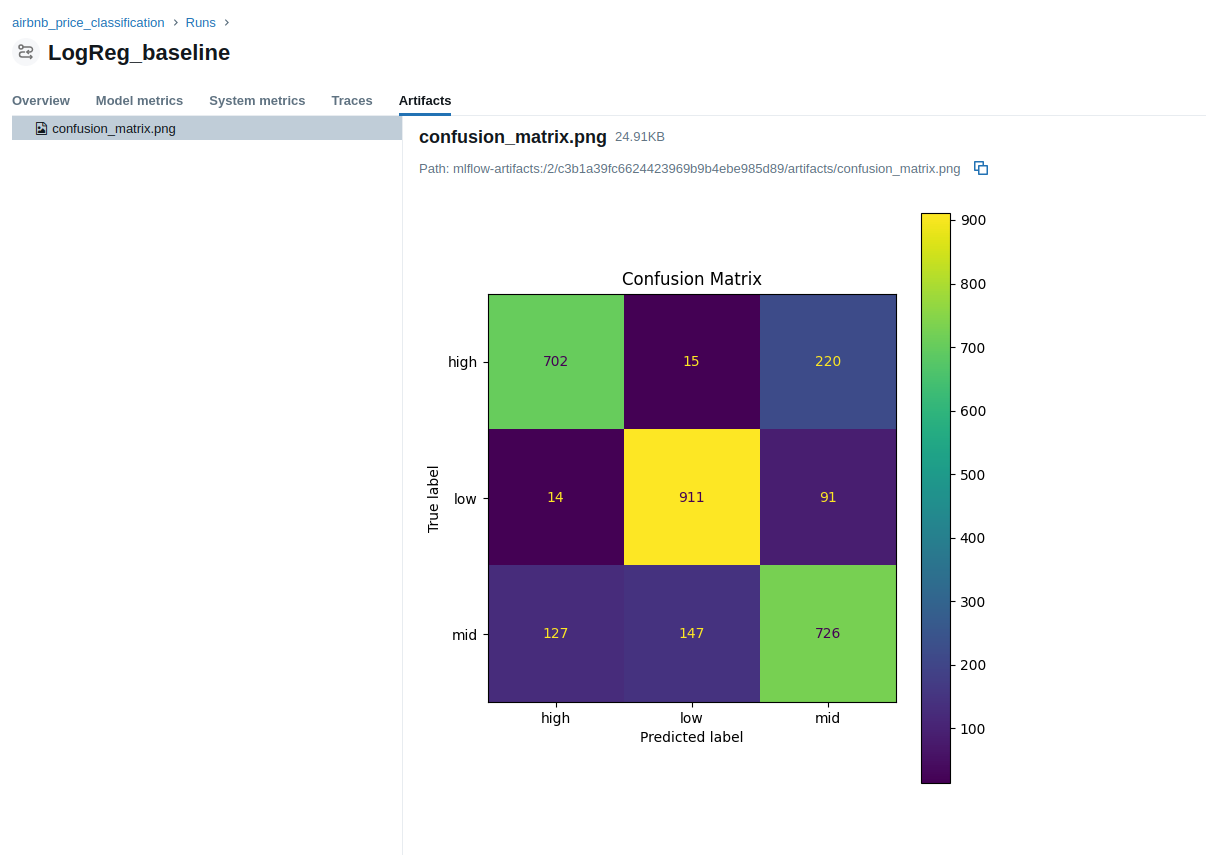

Segundo run: RandomForest

In [15]:
from sklearn.ensemble import RandomForestClassifier
import mlflow
import mlflow.sklearn

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=0
    ))
])

with mlflow.start_run(run_name="RandomForest_baseline"):

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 50)
    mlflow.log_param("max_depth", None)

    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="macro")
    rec = recall_score(y_test, pred, average="macro")
    f1 = f1_score(y_test, pred, average="macro")

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision_macro", prec)
    mlflow.log_metric("recall_macro", rec)
    mlflow.log_metric("f1_macro", f1)

     #matriz de confusion
    fig, ax = plt.subplots(figsize=(6,6))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax)
    plt.title("Confusion Matrix")
    plt.tight_layout()

    fig_path = "confusion_matrix.png"
    plt.savefig(fig_path)
    plt.close()

    mlflow.log_artifact(fig_path)

    # model
    mlflow.sklearn.log_model(clf, artifact_path="model")

    print(acc, prec, rec, f1)

2026/03/01 12:58:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 12:58:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


0.7809007788689468 0.783413668539338 0.7790273251595953 0.7789530251722289
🏃 View run RandomForest_baseline at: http://127.0.0.1:5000/#/experiments/2/runs/e357fe5cb7ac4d3f83a2c13532cfbe98
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


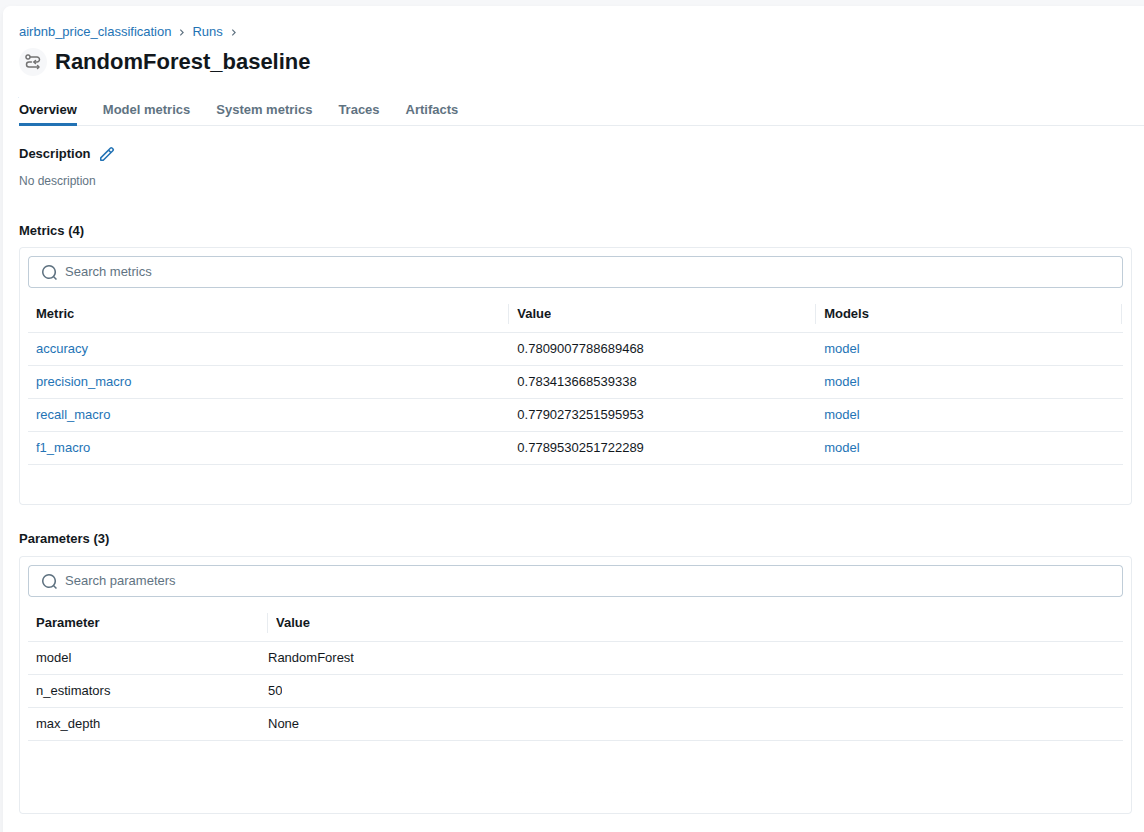

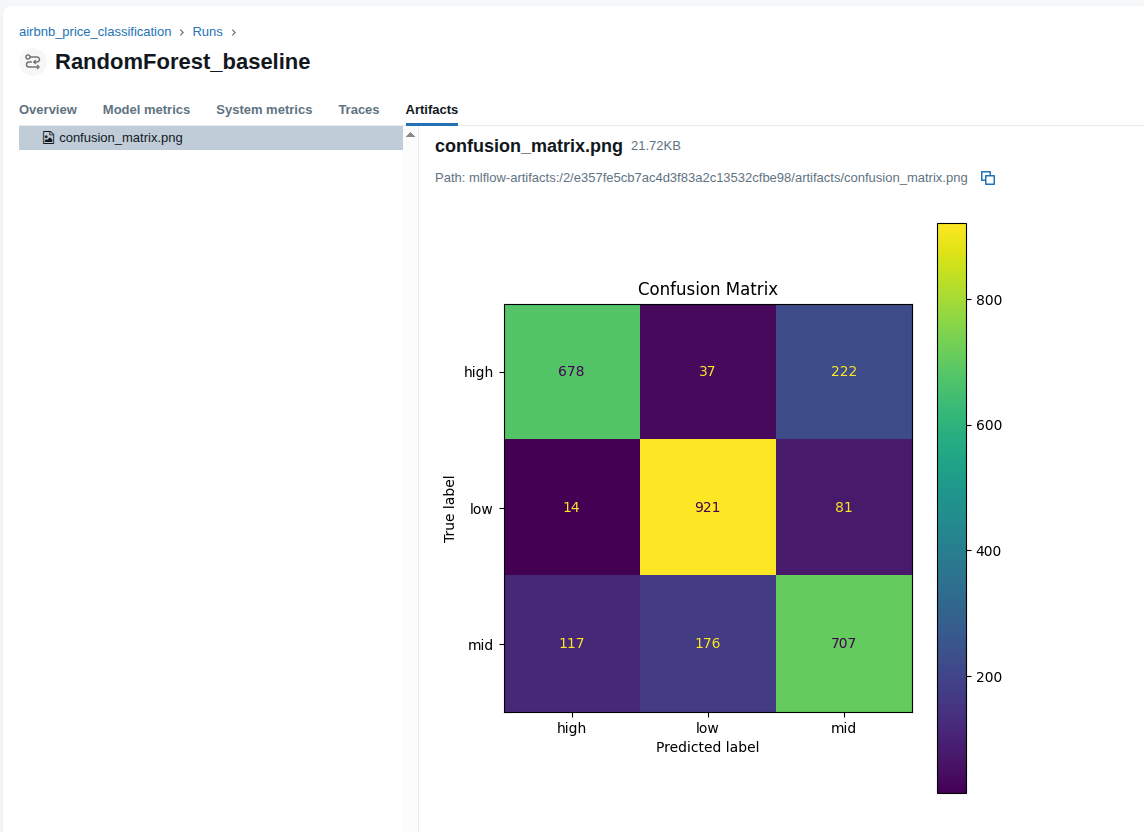

Comparar modelos en MLflow

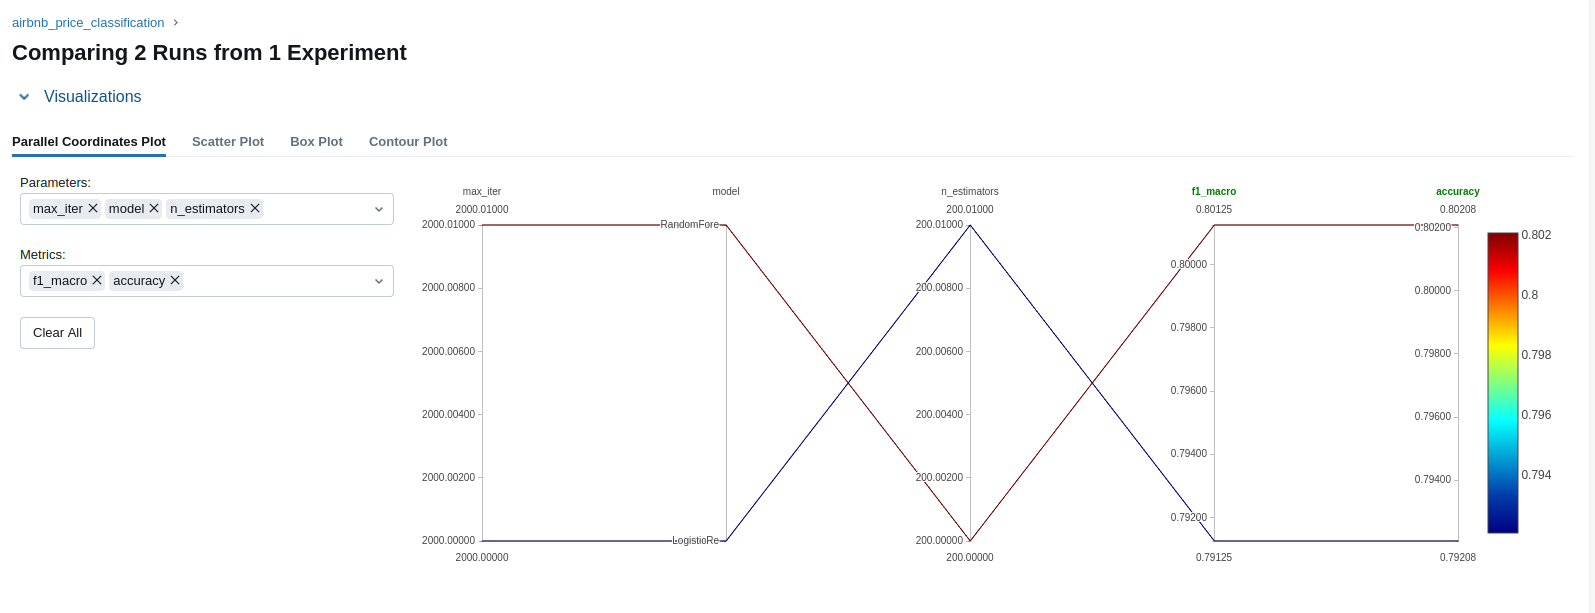

Se entrenaron dos modelos de clasificación: Logistic Regression y Random Forest.
Tras comparar las métricas en MLflow, el modelo que obtuvo mejor F1-score y Accuracy macro fue RandomForest.

## Generar .py de funciones y main con al menos dos argumentos de entrada.

In [3]:
pwd

'/home/ruijia/Descargas'

In [13]:
cd ~/Escritorio/mlops\ practica

/home/ruijia/Escritorio/mlops practica


In [14]:
!python main.py RandomForest 50

2026/03/01 13:20:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 13:20:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
0.7798848628513376 0.7774864765481907


In [15]:
!python main.py LogisticRegression 50

/home/ruijia/anaconda3/envs/bd16-mlops/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
2026/03/01 13:21:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 13:21:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended saf

## Práctica parte FastAPI

### Para esta parte de la práctica teneis que generar un script con al menos 5 modulos app.get y dos de ellos tienen que ser pipelines de HF.

### Parte de la practica se tendra que entregar en capturas de pantalla. Las capturas de pantalla a adjuntas son las siguientes.

### 1. Captura de la pantalla docs con al menos 5 modulos.
### 2. Captura de cada una de los modulos con la respuesta dentro de docs.
### 3. Captura de cada uno de los modulos en la llamada https.
### 4. Todo el codigo usado durante el proceso. Notebooks y scripts.

### Opcional

### 5. Despliegue del script en GCP Cloud Run

Para esta parte, los archivos relevantes se encuentran en la carpeta llamada fastapi_app

Captura de pantalla de los 5 módulos
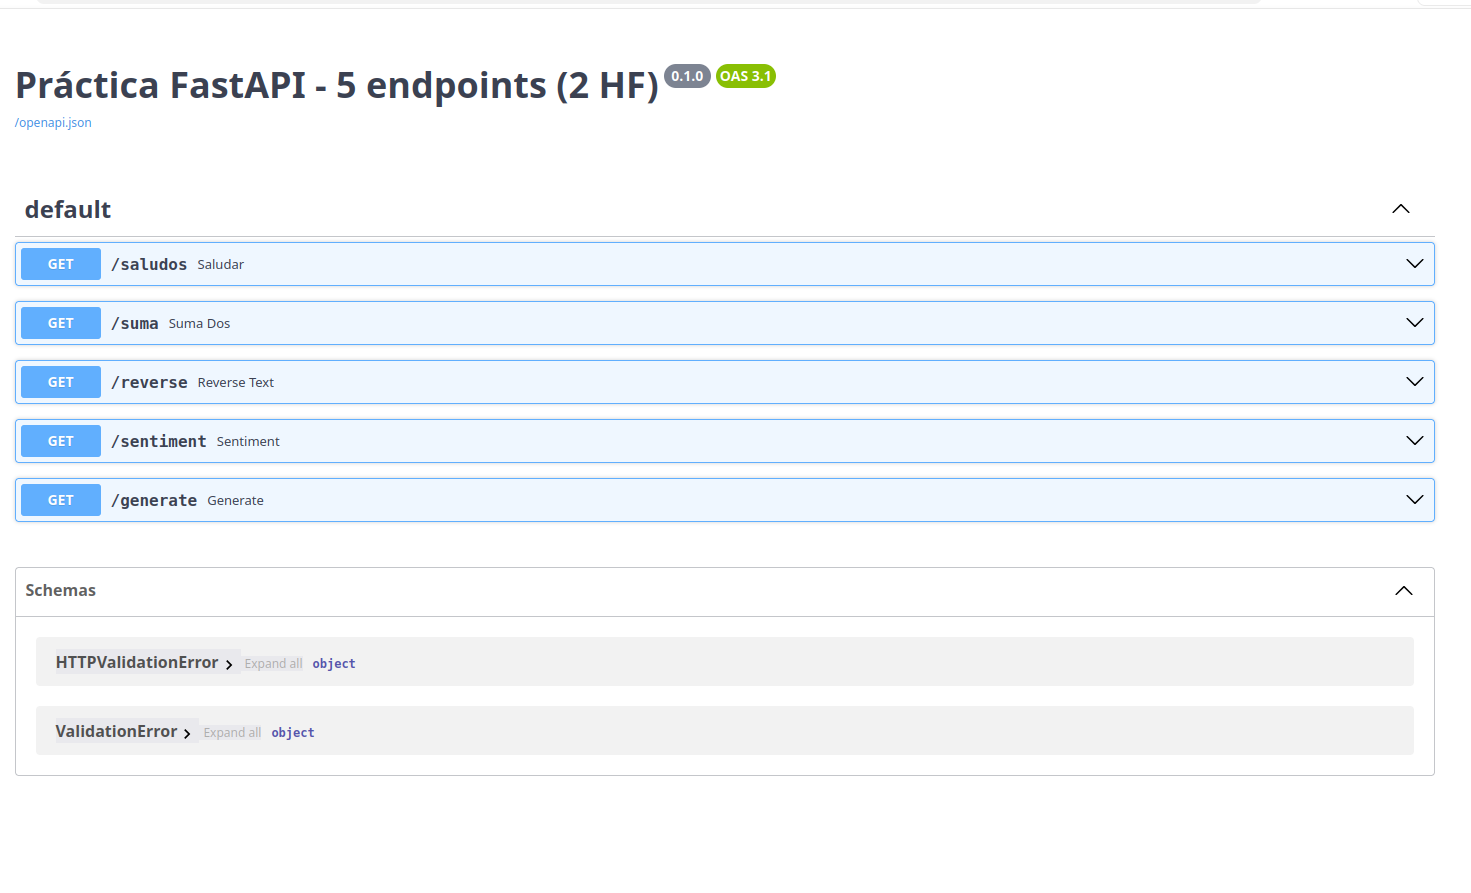

Primer Módulo
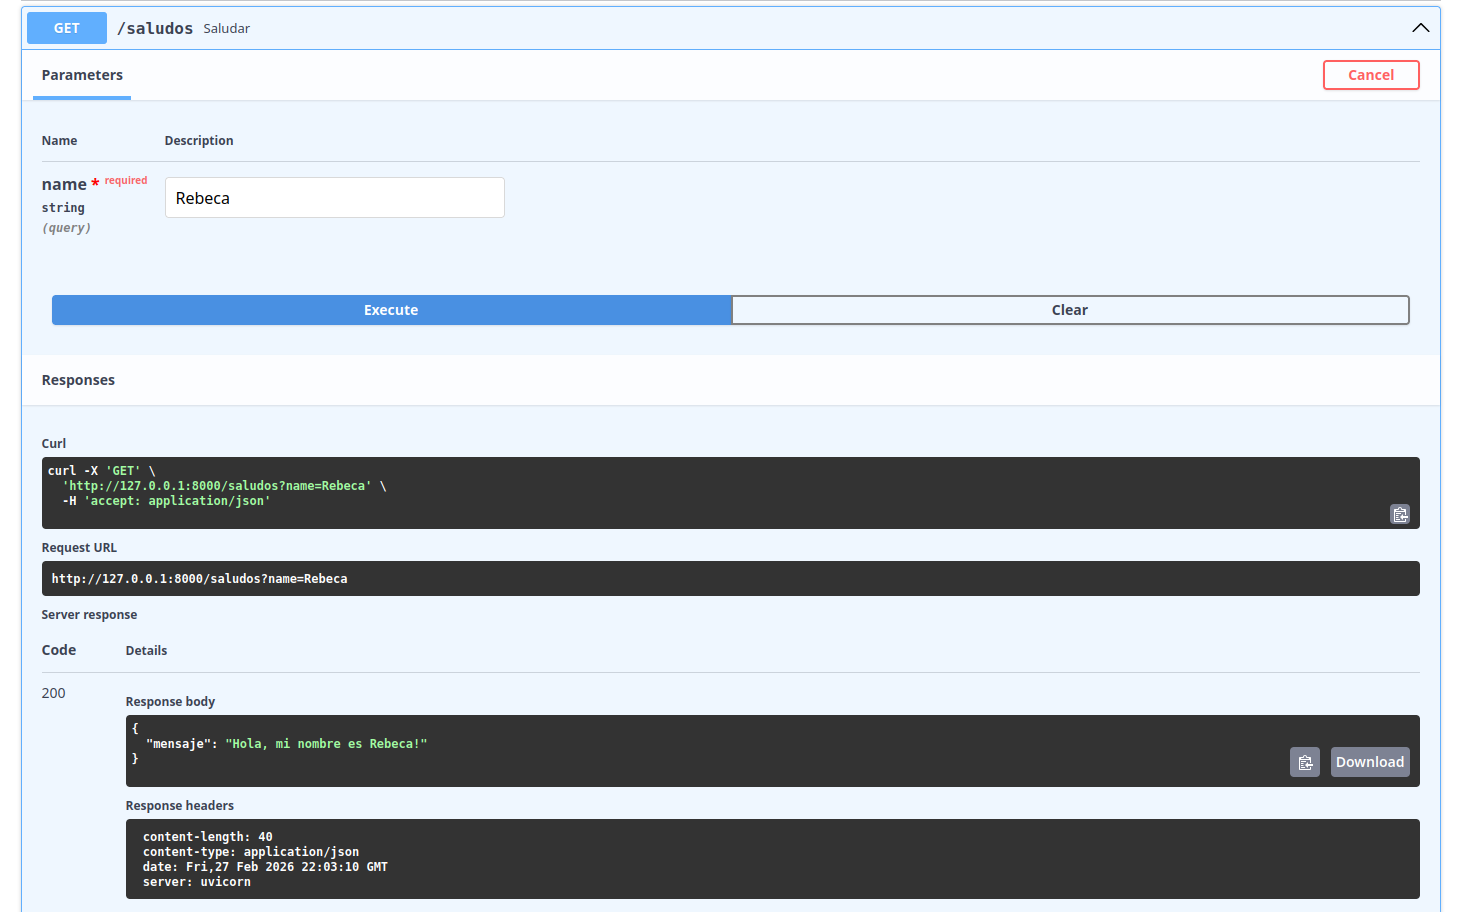

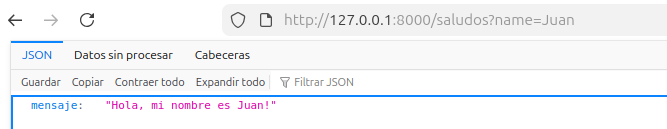

Segundo módulo:
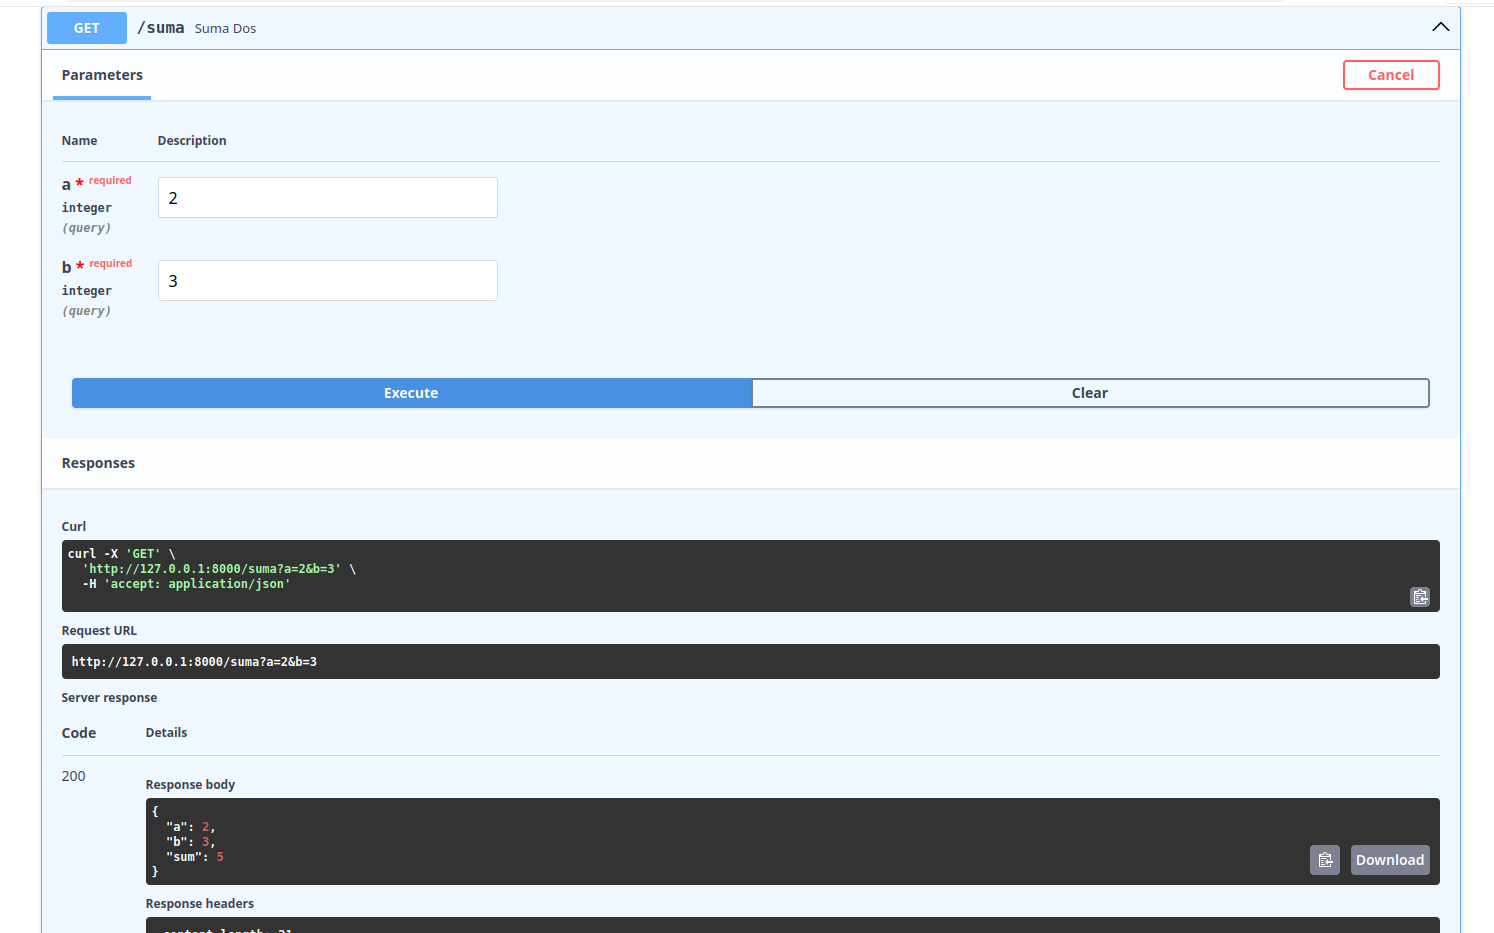

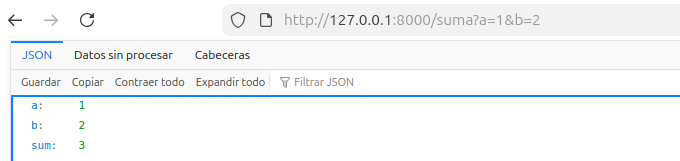

Tercer módulo:
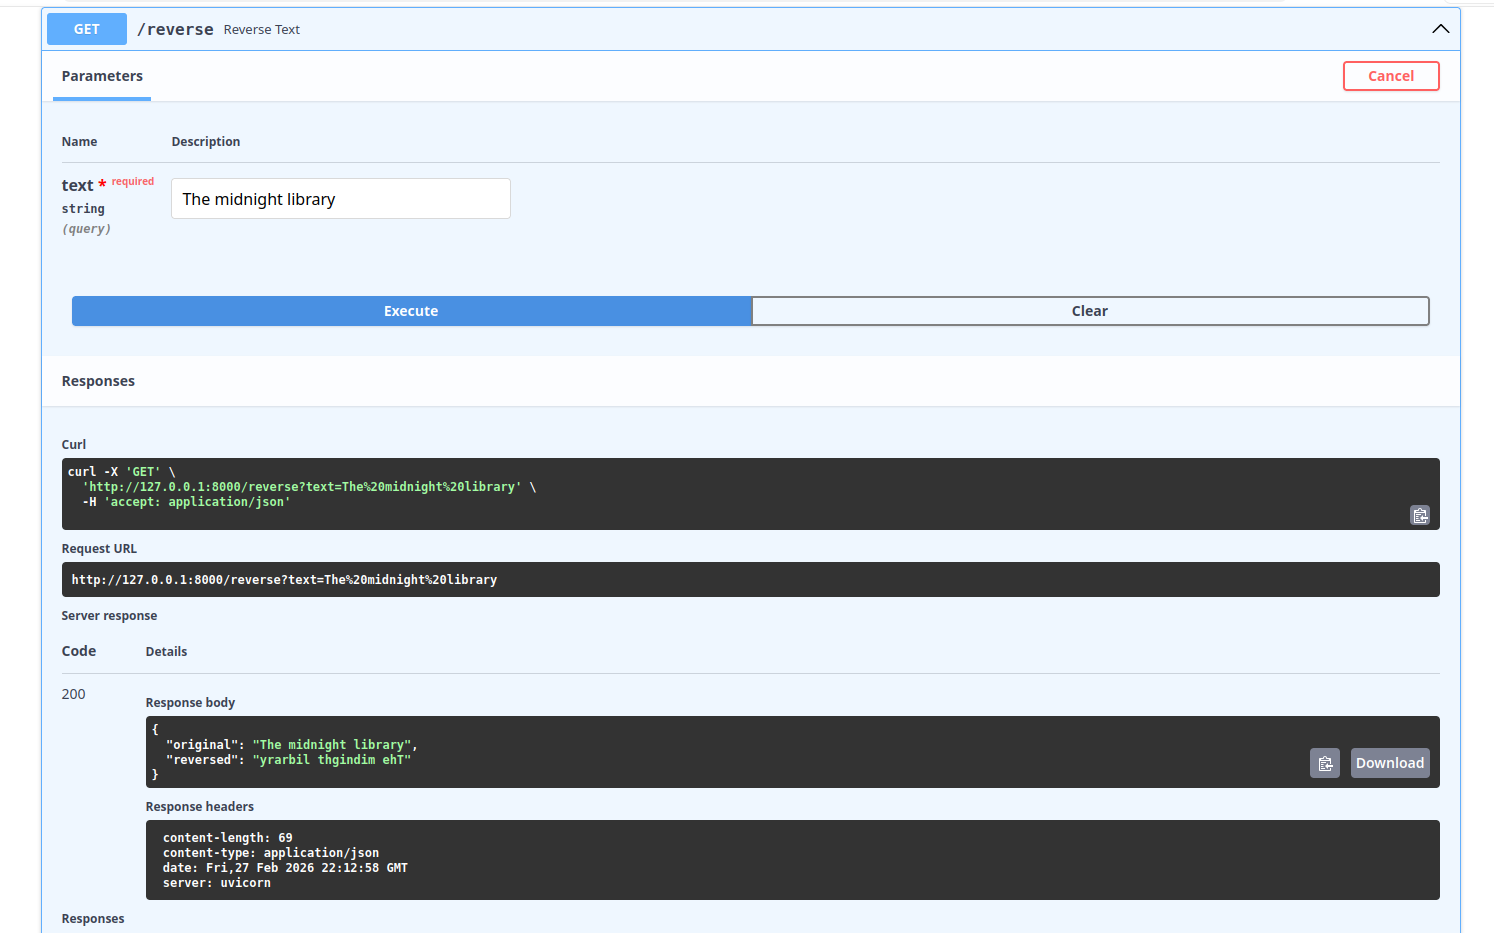

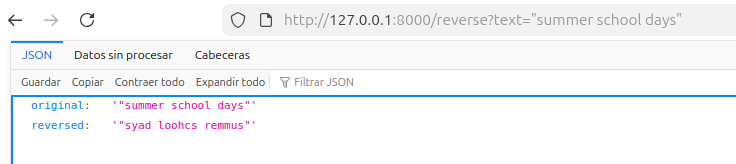

Cuarto módulo
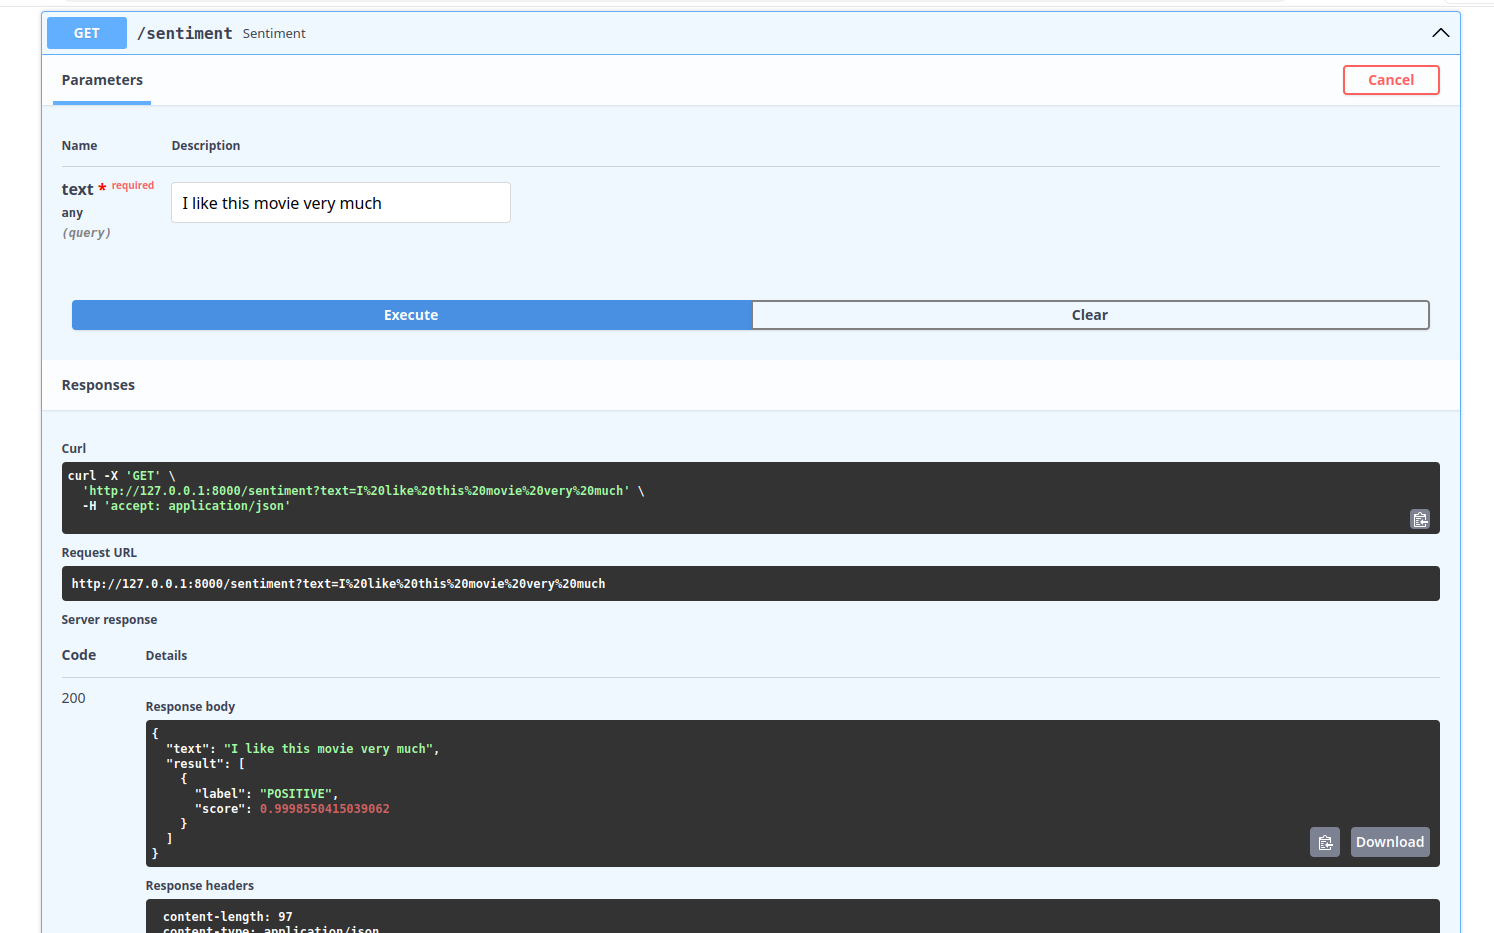

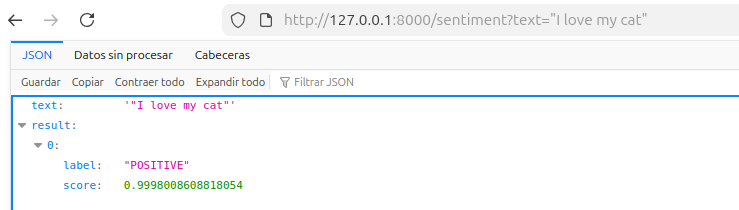

Quinto Módulo
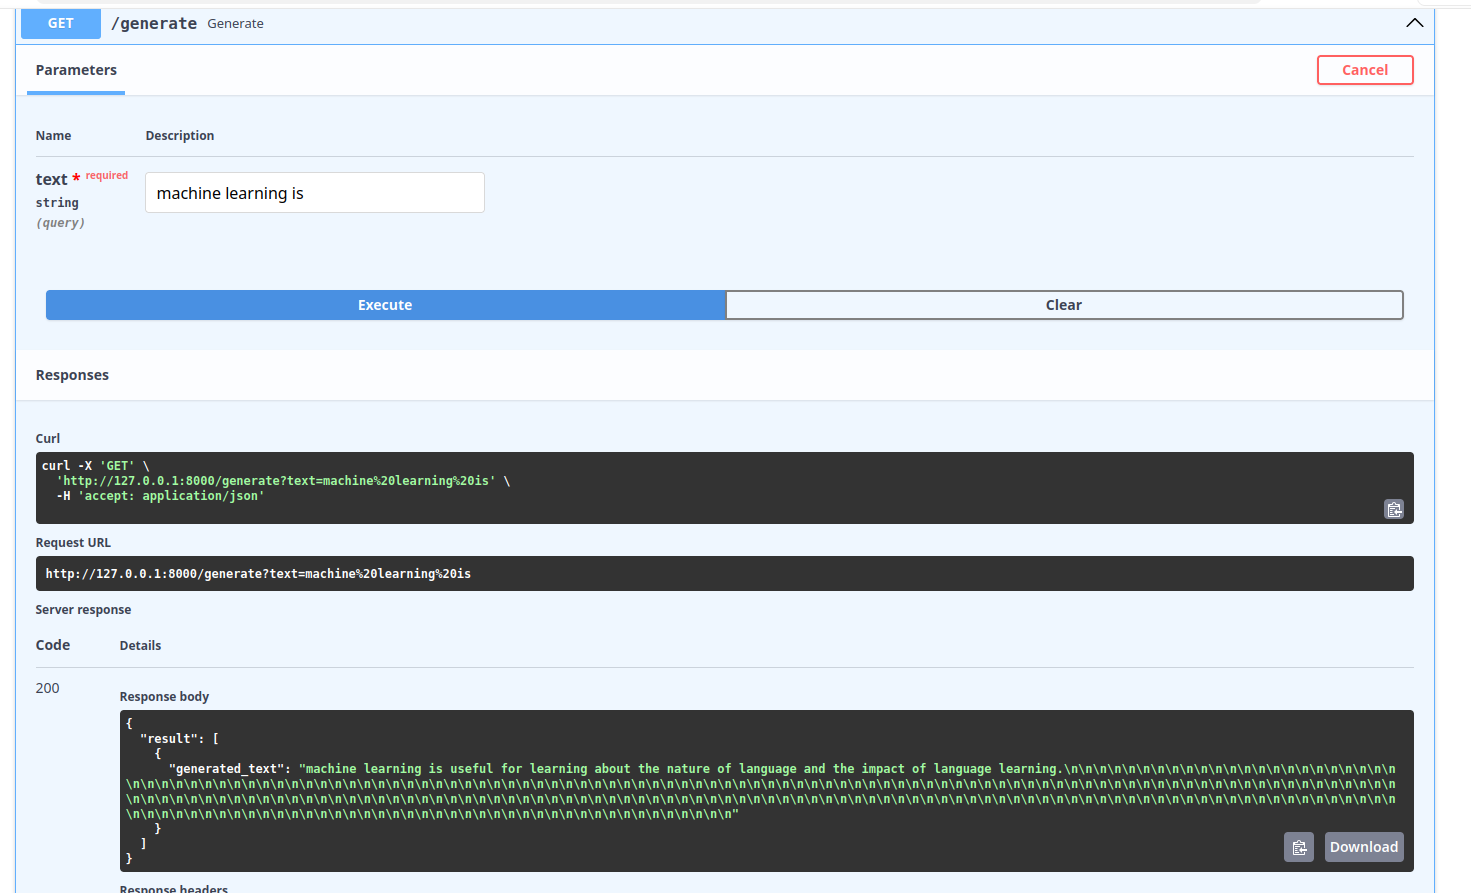

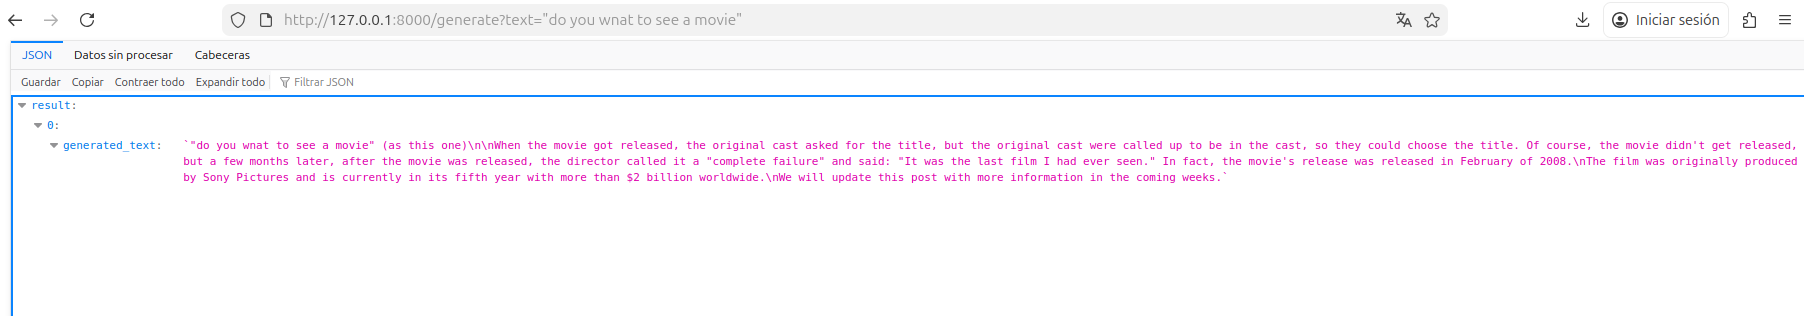

## Reflexión de la parte opcional
Al subir la imagen al cloud, me encontré con varios errores de permisos. Tuve que conceder permisos a distintos servicios, como Service Account, Cloud Build, Logs y Storage, para que funcionara correctamente.

Finalmente, la imagen se subió correctamente al cloud.

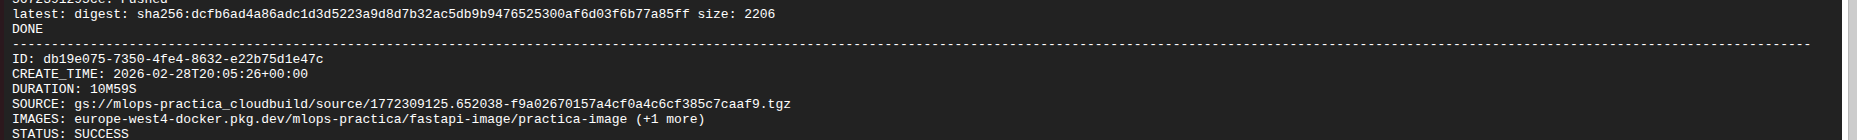

Cloud deployment con éxito:

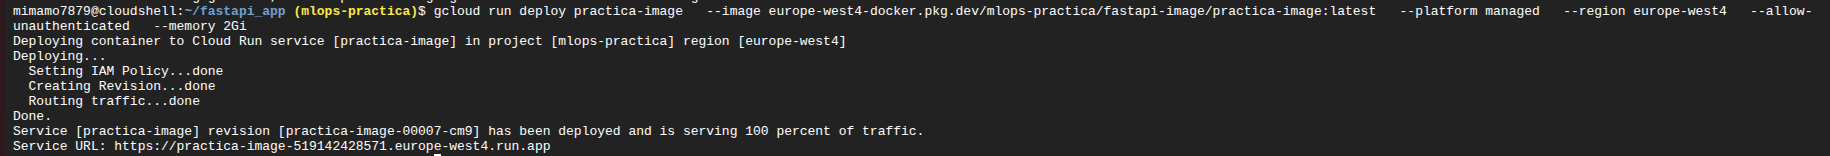

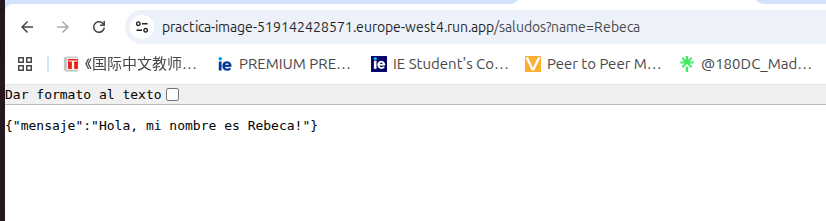

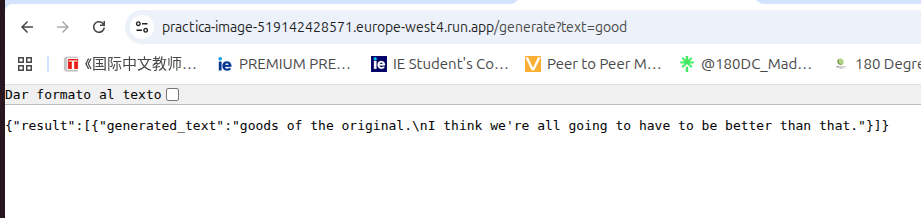

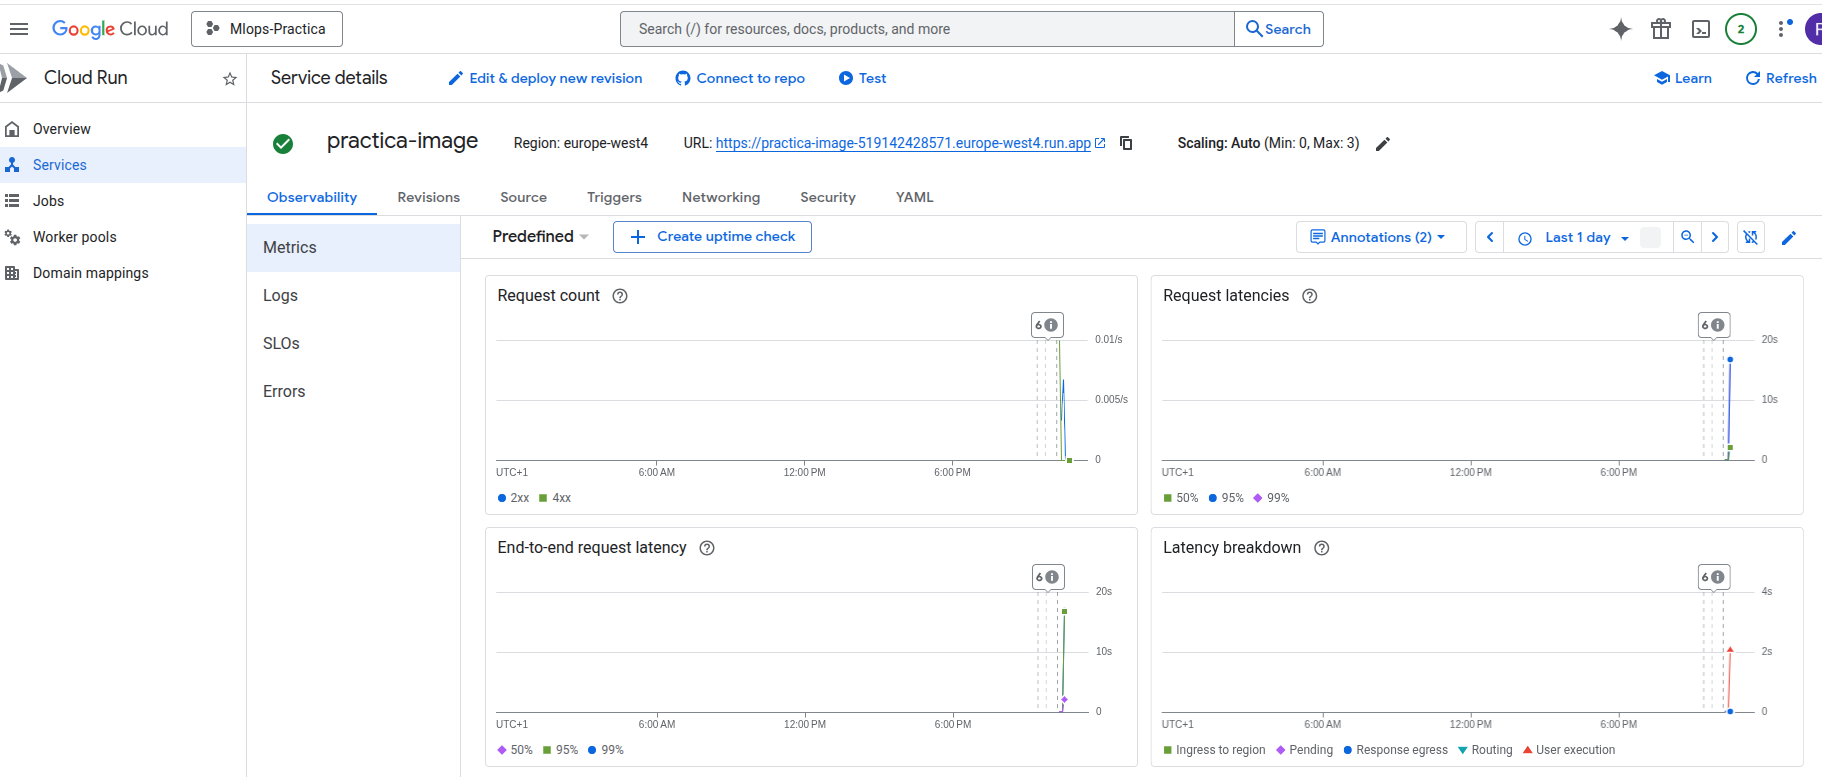

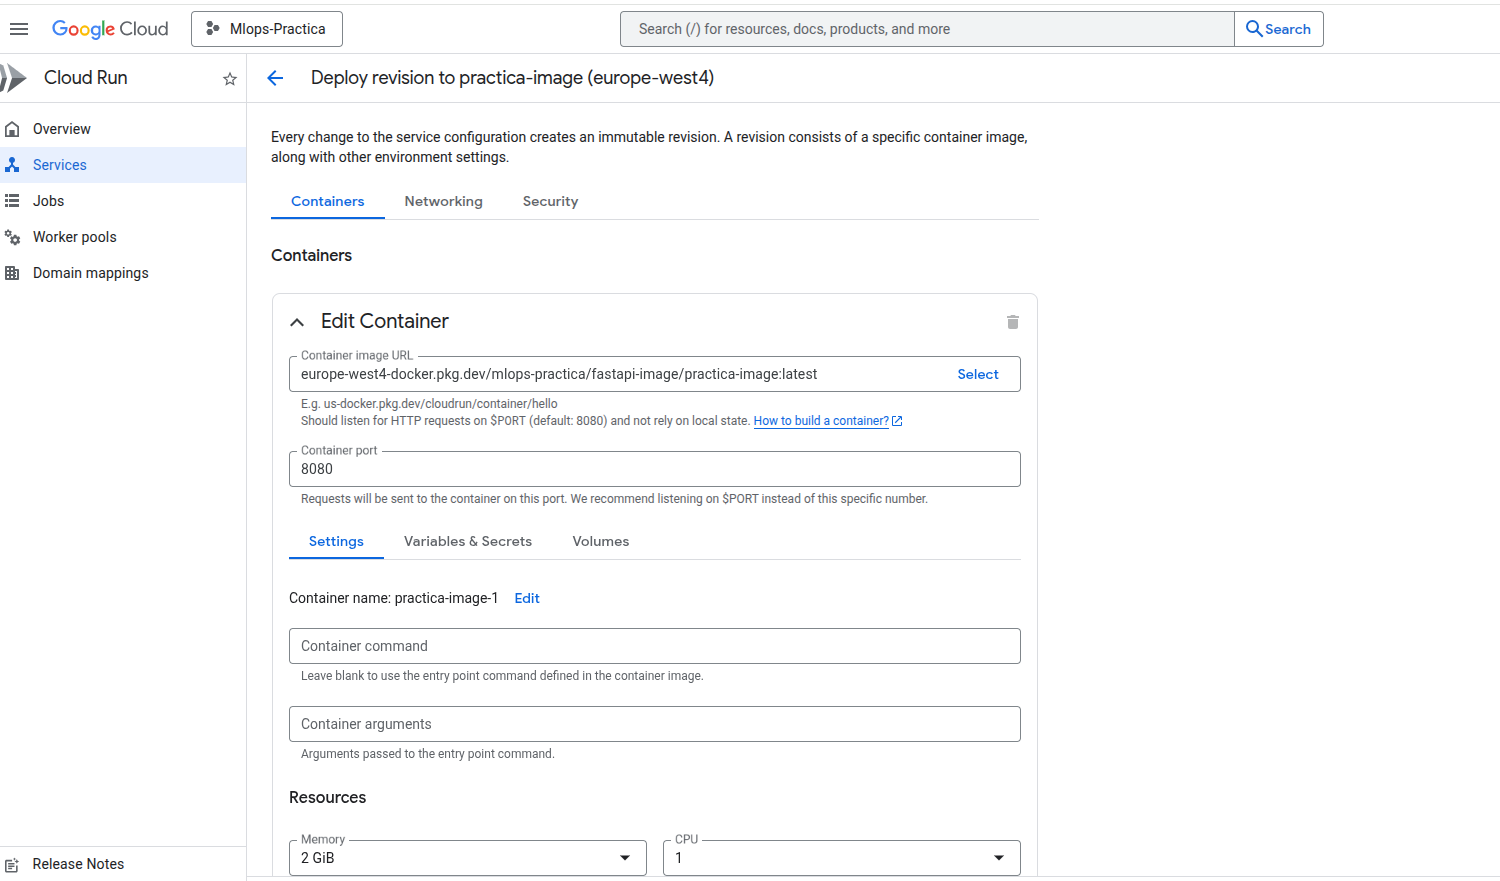